<a href="https://colab.research.google.com/github/Ashutos0762/Reservoir_MBE_Solvers/blob/main/ML_DriveMechanism_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#All Cases Summary


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import warnings; warnings.filterwarnings('ignore')

print("=" * 70)
print("  HAVLENA-ODEH MBE SOLVER — PROJECT SUMMARY")
print("=" * 70)

summary = pd.DataFrame({
    'Case': [1, 2, 3, 4, 5, 6],
    'Drive Type': ['Undersaturated', 'Saturated Depletion', 'Gas Cap',
                   'Water Drive', 'Combination', 'Pressure Estimation'],
    'Plot': ['F vs (Eo+Efw)', 'krg/kro vs Sg', 'F/Eo vs Eg/Eo',
             'F/Eo vs dP/Eo', 'Multi-Regression', 'LHS vs RHS intersection'],
    'Unknowns': ['N', 'So, Sg, krg/kro', 'N, m', 'N, K', 'N, m, K', 'P_avg']
})
print(summary.to_string(index=False))

  HAVLENA-ODEH MBE SOLVER — PROJECT SUMMARY
 Case          Drive Type                    Plot        Unknowns
    1      Undersaturated           F vs (Eo+Efw)               N
    2 Saturated Depletion           krg/kro vs Sg So, Sg, krg/kro
    3             Gas Cap           F/Eo vs Eg/Eo            N, m
    4         Water Drive           F/Eo vs dP/Eo            N, K
    5         Combination        Multi-Regression         N, m, K
    6 Pressure Estimation LHS vs RHS intersection           P_avg


#Campbell Diagnostic Plot(Wronng model identification)

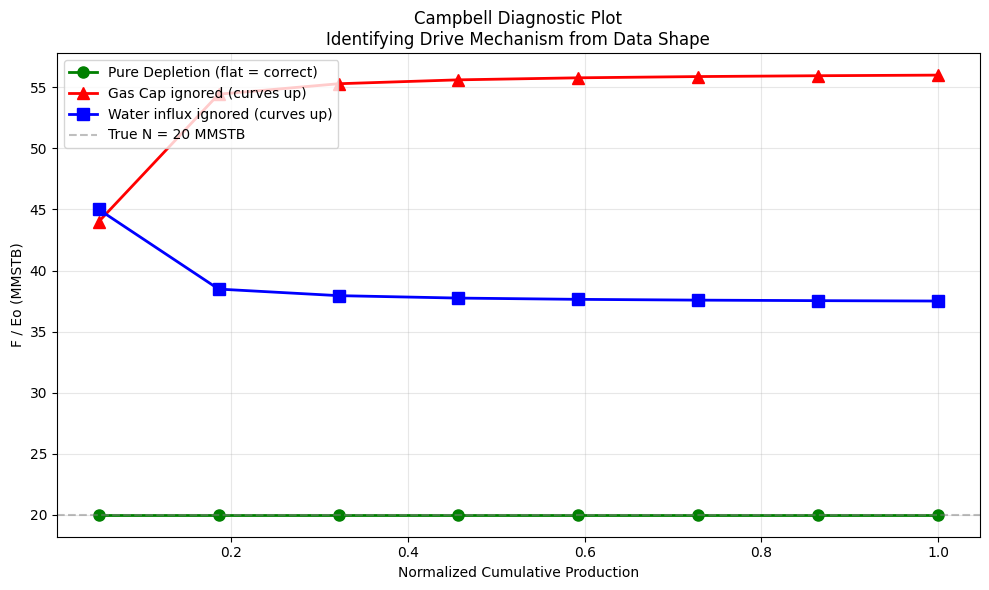

If F/Eo is flat → depletion drive model is correct
If F/Eo curves upward → additional energy source exists (gas cap or aquifer)


In [ ]:
# Campbell Plot: F/Eo vs Np
# If model is correct → flat line at N
# If it curves up → unaccounted water influx or gas cap

Eo = np.linspace(0.01, 0.4, 8)
Eg = np.linspace(0.02, 1.2, 8)
dP = np.linspace(50, 1400, 8)
N_true = 20e6

# 3 scenarios
F_depletion = N_true * Eo
F_gascap    = N_true * Eo + N_true * 0.6 * Eg
F_water     = N_true * Eo + 5000 * dP
Np_norm     = np.linspace(0.05, 1.0, 8)  # normalized Np

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(Np_norm, F_depletion / Eo / 1e6, 'go-', ms=8, lw=2, label='Pure Depletion (flat = correct)')
ax.plot(Np_norm, F_gascap / Eo / 1e6, 'r^-', ms=8, lw=2, label='Gas Cap ignored (curves up)')
ax.plot(Np_norm, F_water / Eo / 1e6, 'bs-', ms=8, lw=2, label='Water influx ignored (curves up)')
ax.axhline(N_true / 1e6, color='gray', ls='--', alpha=0.5, label=f'True N = {N_true/1e6:.0f} MMSTB')

ax.set_xlabel('Normalized Cumulative Production')
ax.set_ylabel('F / Eo (MMSTB)')
ax.set_title('Campbell Diagnostic Plot\nIdentifying Drive Mechanism from Data Shape')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("If F/Eo is flat → depletion drive model is correct")
print("If F/Eo curves upward → additional energy source exists (gas cap or aquifer)")

#ML based Classifier

*Synthetic Data Generator*



In [ ]:
np.random.seed(42)
n_samples = 300

Eo_base = np.linspace(0.01, 0.4, 8)
Eg_base = np.linspace(0.02, 1.2, 8)
dP_base = np.linspace(50, 1400, 8)

features, labels = [], []

for _ in range(n_samples):
    N = np.random.uniform(5e6, 50e6)
    noise = np.random.normal(1, 0.03, 8)

    for drive, F in [
        ('Depletion',    N * Eo_base * noise),
        ('Gas Cap',      N * (Eo_base + np.random.uniform(0.3, 2.0) * Eg_base) * noise),
        ('Water Drive',  (N * Eo_base + np.random.uniform(2000, 15000) * dP_base) * noise),
        ('Combination',  (N * (Eo_base + np.random.uniform(0.3, 2.0) * Eg_base) +
                          np.random.uniform(2000, 15000) * dP_base) * noise),
    ]:
        # Estimate N_rough from linear fit of F vs Eo
        sl, _, r, _, _ = linregress(Eo_base, F)
        deviation = F - sl * Eo_base

        features.append([
            r**2,                                           # R² of F vs Eo
            np.corrcoef(deviation, Eg_base)[0, 1],          # correlation with Eg
            np.corrcoef(deviation, dP_base)[0, 1],          # correlation with dP
            np.std(deviation) / np.mean(F),                 # relative deviation
        ])
        labels.append(drive)

X = np.array(features)
y = np.array(labels)
feature_names = ['R² (F vs Eo)', 'Corr(dev, Eg)', 'Corr(dev, dP)', 'Rel. Deviation']

print(f"Generated {len(y)} samples: {np.unique(y, return_counts=True)}")

Generated 1200 samples: (array(['Combination', 'Depletion', 'Gas Cap', 'Water Drive'], dtype='<U11'), array([300, 300, 300, 300]))


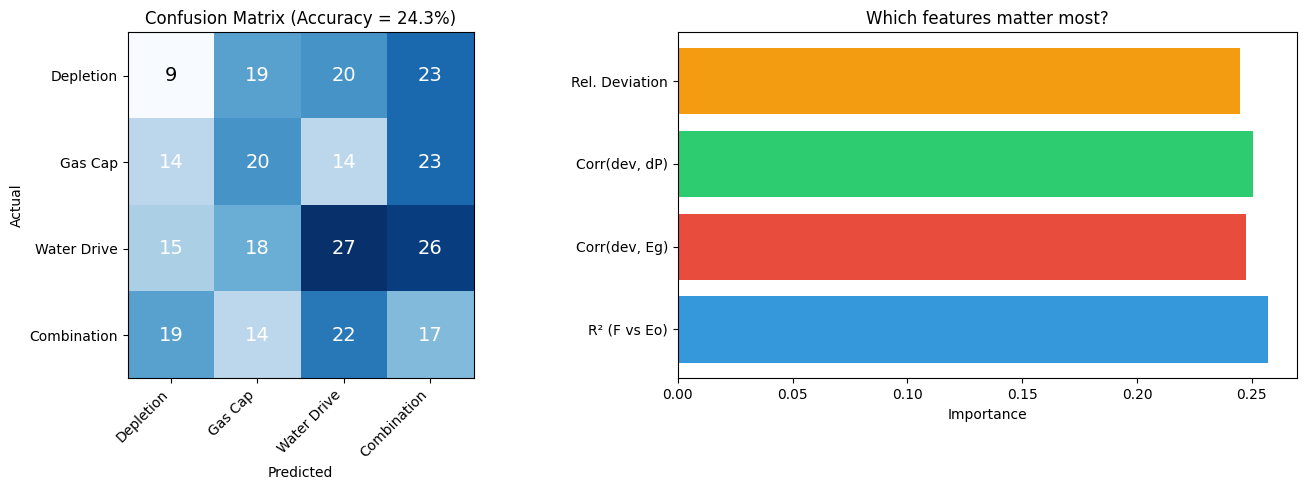

              precision    recall  f1-score   support

 Combination       0.19      0.24      0.21        72
   Depletion       0.16      0.13      0.14        71
     Gas Cap       0.28      0.28      0.28        71
 Water Drive       0.33      0.31      0.32        86

    accuracy                           0.24       300
   macro avg       0.24      0.24      0.24       300
weighted avg       0.24      0.24      0.24       300



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

accuracy = (y_pred == y_test).mean()

# Confusion matrix
labels_unique = ['Depletion', 'Gas Cap', 'Water Drive', 'Combination']
cm = confusion_matrix(y_test, y_pred, labels=labels_unique)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
im = ax1.imshow(cm, cmap='Blues')
ax1.set_xticks(range(4)); ax1.set_yticks(range(4))
ax1.set_xticklabels(labels_unique, rotation=45, ha='right')
ax1.set_yticklabels(labels_unique)
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.set_title(f'Confusion Matrix (Accuracy = {accuracy*100:.1f}%)')
for i in range(4):
    for j in range(4):
        ax1.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

# Feature importance
imp = clf.feature_importances_
ax2.barh(feature_names, imp, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
ax2.set_xlabel('Importance')
ax2.set_title('Which features matter most?')

plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred))

In [ ]:
# Simulate a new unknown reservoir → is it gas cap or water drive?
N_new = 25e6
F_new = N_new * (Eo_base + 1.2 * Eg_base) + 4000 * dP_base  # combination drive

sl, _, r, _, _ = linregress(Eo_base, F_new)
dev = F_new - sl * Eo_base

new_features = [[
    r**2,
    np.corrcoef(dev, Eg_base)[0, 1],
    np.corrcoef(dev, dP_base)[0, 1],
    np.std(dev) / np.mean(F_new),
]]

prediction = clf.predict(new_features)[0]
probabilities = clf.predict_proba(new_features)[0]

print("New Reservoir Prediction:")
print(f"  Predicted Drive Type: {prediction}")
print(f"\n  Confidence:")
for label, prob in zip(clf.classes_, probabilities):
    bar = '█' * int(prob * 30)
    print(f"    {label:15s}: {prob*100:5.1f}% {bar}")

New Reservoir Prediction:
  Predicted Drive Type: Combination

  Confidence:
    Combination    :  59.0% █████████████████
    Depletion      :  23.0% ██████
    Gas Cap        :   7.0% ██
    Water Drive    :  11.0% ███


In [ ]:
print("=" * 65)
print("  HAVLENA-ODEH MBE SOLVER — COMPLETE")
print("=" * 65)
print()
print("  Notebooks:")
print("  ├── case1.ipynb  →  Undersaturated (F vs Eo+Efw)")
print("  ├── case2.ipynb  →  Saturated Depletion (So, Sg, krg/kro)")
print("  ├── case3.ipynb  →  Gas Cap Drive (F/Eo vs Eg/Eo)")
print("  ├── case4.ipynb  →  Water Drive — Pot Aquifer (F/Eo vs dP/Eo)")
print("  ├── case5.ipynb  →  Combination Drive (Multi-Regression)")
print("  ├── case6.ipynb  →  Pressure Estimation (LHS-RHS intersection)")
print("  └── ML_Drive_Mechanism_Classifier.ipynb → Summary + ML Classifier")
print()
print("  Tools Used:")
print("    numpy, pandas, matplotlib, scipy, scikit-learn")
print()
print("  Key Skills Demonstrated:")
print("    - Material Balance Equation for all drive mechanisms")
print("    - Havlena-Odeh straight-line analysis")
print("    - PVT property handling and interpolation")
print("    - Sensitivity analysis")
print("    - Campbell diagnostic plots")
print("    - ML-based drive mechanism classification")

  HAVLENA-ODEH MBE SOLVER — COMPLETE

  Notebooks:
  ├── case1.ipynb  →  Undersaturated (F vs Eo+Efw)
  ├── case2.ipynb  →  Saturated Depletion (So, Sg, krg/kro)
  ├── case3.ipynb  →  Gas Cap Drive (F/Eo vs Eg/Eo)
  ├── case4.ipynb  →  Water Drive — Pot Aquifer (F/Eo vs dP/Eo)
  ├── case5.ipynb  →  Combination Drive (Multi-Regression)
  ├── case6.ipynb  →  Pressure Estimation (LHS-RHS intersection)
  └── ML_Drive_Mechanism_Classifier.ipynb → Summary + ML Classifier

  Tools Used:
    numpy, pandas, matplotlib, scipy, scikit-learn

  Key Skills Demonstrated:
    - Material Balance Equation for all drive mechanisms
    - Havlena-Odeh straight-line analysis
    - PVT property handling and interpolation
    - Sensitivity analysis
    - Campbell diagnostic plots
    - ML-based drive mechanism classification
